In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)

df = pd.read_csv("master_dataset_modelling.csv")

df['QuarterEnd'] = pd.to_datetime(df['QuarterEnd'])
df = df.sort_values('QuarterEnd').reset_index(drop=True)

print(df.shape)
df.head()


/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (
2025-11-27 16:40:03.625454: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


(43, 15)


,Y_Cost_Per_Ton,QuarterEnd,X1_Scrap_Price,X2_Electricity_Price,X3_Natural_Gas_Price,X4_Diesel_Price,X5_Rail_Price,X6_Disaster_Cost_Sum,X7_Hourly_Wage,X8_US_Scrap_Exports,X9_US_Dollar_Index,X10_Graphite_Price,X11_Economic_Policy_Uncertainty,X12_Inventory_Turnover,X13_PPI_All_Commodities
0,729.575510,2015-03-31,174.500000,6.773333,2.896667,2.917333,182.600000,9998.6,24.800000,2.258731e+09,105.473017,162.466667,101.377553,1.596272,191.533333
1,655.871676,2015-06-30,165.100000,7.100000,2.746667,2.847667,179.833333,15643.9,24.943333,2.719429e+09,105.997159,161.400000,107.247981,1.699568,193.033333
2,629.216046,2015-09-30,161.400000,7.146667,2.756667,2.629333,178.800000,0.0,25.070000,2.308197e+09,109.626666,161.000000,142.390361,1.599527,191.633333
3,656.977971,2015-12-31,155.700000,6.500000,2.120000,2.432000,176.666667,5266.9,25.233333,1.985767e+09,111.474224,160.200000,100.749685,1.508865,185.566667
4,557.681848,2016-03-31,154.166667,6.440000,2.000000,2.077000,174.000000,13371.5,25.400000,1.592065e+09,113.609032,159.433333,144.556417,1.651029,182.000000


In [2]:
def add_lagged_features(df, lags=[1, 2, 3]):
    """
    Automatically creates lagged versions of ALL numeric columns
    except 'Year' and date columns.

    Example:
    Cost_per_Ton_lag1, Cost_per_Ton_lag2, GDP_lag1, Inflation_lag3, etc.
    """
    import pandas as pd

    df = df.copy()
    numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

    # Columns you DON'T want to lag
    ignore = ["Year"] 

    numeric_cols = [c for c in numeric_cols if c not in ignore]

    for col in numeric_cols:
        for lag in lags:
            df[f"{col}_lag{lag}"] = df[col].shift(lag)

    return df


print(tf.constant([1,2,3]) + 5)


tf.Tensor([6 7 8], shape=(3,), dtype=int32)


In [3]:
# 1. generate lagged features
df_lagged = add_lagged_features(df, lags=[1, 2, 3])

# 2. Drop NA created by lagging
df_lagged = df_lagged.dropna().reset_index(drop=True)

# 3. Target
target_col = "Y_Cost_Per_Ton"

# 4. Features selection
base_features = [
    'X1_Scrap_Price',       
    'X8_US_Scrap_Exports_lag1',  
    'X13_PPI_All_Commodities',
    "Y_Cost_Per_Ton_lag1"
]

missing = [c for c in [target_col] + base_features if c not in df_lagged.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

# 6. final dataset
data_raw = df_lagged[[target_col] + base_features].copy()

# 7. scale data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_raw.values)


In [4]:
data_raw.head()

,Y_Cost_Per_Ton,X1_Scrap_Price,X8_US_Scrap_Exports_lag1,X13_PPI_All_Commodities,Y_Cost_Per_Ton_lag1
0,656.977971,155.700000,2.308197e+09,185.566667,629.216046
1,557.681848,154.166667,1.985767e+09,182.000000,656.977971
2,569.848536,159.766667,1.592065e+09,185.366667,557.681848
3,622.499575,164.366667,2.047448e+09,187.066667,569.848536
4,708.041096,161.766667,1.955132e+09,187.066667,622.499575


In [5]:
def make_windowed_dataset(data_2d, window_size=4):
    """
    data_2d: numpy array shape (n_samples, n_features)
             col 0 = Y_Cost_Per_Ton (scaled), rest = features
    window_size: number of past steps to use
    
    Returns:
        X: (n_windows, window_size, n_features)
        y: (n_windows,) future target (unscaled, but here scaled because col0 is scaled)
    """
    X_list = []
    y_list = []
    
    n = data_2d.shape[0]
    for i in range(n - window_size):
        window = data_2d[i:i+window_size, :]      # shape (window_size, n_features)
        target = data_2d[i+window_size, 0]        # future Y (col 0)
        X_list.append(window)
        y_list.append(target)
    
    X = np.array(X_list)
    y = np.array(y_list)
    return X, y

WINDOW_SIZE = 4
X_all, y_all = make_windowed_dataset(data_scaled, window_size=WINDOW_SIZE)

X_all.shape, y_all.shape


((36, 4, 5), (36,))

In [6]:
n_samples = X_all.shape[0]

train_end = int(n_samples * 0.7)
val_end   = int(n_samples * 0.85)

X_train = X_all[:train_end]
y_train = y_all[:train_end]

X_val   = X_all[train_end:val_end]
y_val   = y_all[train_end:val_end]

X_test  = X_all[val_end:]
y_test  = y_all[val_end:]

X_train.shape, X_val.shape, X_test.shape


((25, 4, 5), (5, 4, 5), (6, 4, 5))

In [7]:
def evaluate_and_print(model, name, X_train, y_train, X_val, y_val, X_test, y_test):
    y_train_pred = model.predict(X_train).flatten()
    y_val_pred = model.predict(X_val).flatten()
    y_test_pred = model.predict(X_test).flatten()

    def metrics(y_true, y_pred):
        mse = mean_squared_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        return rmse, mae, r2

    rmse_tr, mae_tr, r2_tr = metrics(y_train, y_train_pred)
    rmse_va, mae_va, r2_va = metrics(y_val, y_val_pred)
    rmse_te, mae_te, r2_te = metrics(y_test, y_test_pred)

    print(f"====== {name} ======")
    print(f"Train   RMSE: {rmse_tr:.3f} | MAE: {mae_tr:.3f} | R2: {r2_tr:.3f}")
    print(f"Val     RMSE: {rmse_va:.3f} | MAE: {mae_va:.3f} | R2: {r2_va:.3f}")
    print(f"Test    RMSE: {rmse_te:.3f} | MAE: {mae_te:.3f} | R2: {r2_te:.3f}")

    return y_train_pred, y_val_pred, y_test_pred

def plot_predictions_scaled(y_true, y_pred, title="Test predictions (scaled)", n_points=None):
    """
    Fancy version of the plot:
    - line + markers
    - error bars (absolute error)
    - MAE / RMSE box on the plot
    """
    y_true = np.asarray(y_true).flatten()
    y_pred = np.asarray(y_pred).flatten()

    if n_points is not None:
        y_true = y_true[:n_points]
        y_pred = y_pred[:n_points]

    x = np.arange(len(y_true))
    errors = np.abs(y_true - y_pred)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    plt.style.use("seaborn-v0_8-darkgrid")  # a bit nicer than default

    fig, ax = plt.subplots(figsize=(10, 5))

    # True vs Pred lines
    ax.plot(x, y_true, marker="o", linewidth=2.5, label="True (scaled)")
    ax.plot(x, y_pred, marker="s", linestyle="--", linewidth=2.5, label="Predicted (scaled)")

    # Error bars (secondary axis)
    ax2 = ax.twinx()
    ax2.bar(x, errors, alpha=0.25, width=0.5, label="|Error|")

    ax.set_title(title, fontsize=14, pad=12)
    ax.set_xlabel("Time step (test set index)")
    ax.set_ylabel("Scaled value")
    ax2.set_ylabel("|Error|")

    # Metrics box on plot
    textstr = f"MAE = {mae:.3f}\nRMSE = {rmse:.3f}"
    ax.text(
        0.02, 0.98, textstr,
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
    )

    # Combine legends from both axes
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines + lines2, labels + labels2, loc="lower right")

    plt.tight_layout()
    plt.show()

def make_callbacks(patience=10):
    return [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=max(2, patience // 2), verbose=0),
    ]


def split_model_params(params, default_batch_size=8):
    params = dict(params)
    batch_size = params.pop("batch_size", default_batch_size)
    return params, batch_size


n_features = X_train.shape[2]


def build_lstm_model(window_size=WINDOW_SIZE, n_features=n_features, units=64, dense_units=32, dropout=0.0, recurrent_dropout=0.0, lr=1e-3):
    model = keras.Sequential([
        layers.Input(shape=(window_size, n_features)),
        layers.LSTM(units, return_sequences=False, dropout=dropout, recurrent_dropout=recurrent_dropout),
        layers.Dense(dense_units, activation="relu"),
        layers.Dense(1),
    ])
    model.compile(loss="mse", optimizer=keras.optimizers.Adam(learning_rate=lr))
    return model


def build_cnn1d_model(window_size=WINDOW_SIZE, n_features=n_features, filters=64, kernel_size=2, dense_units=32, dropout=0.0, lr=1e-3):
    model = keras.Sequential([
        layers.Input(shape=(window_size, n_features)),
        layers.Conv1D(filters, kernel_size=kernel_size, activation="relu", padding="causal"),
        layers.Dropout(dropout),
        layers.GlobalMaxPooling1D(),
        layers.Dense(dense_units, activation="relu"),
        layers.Dense(1),
    ])
    model.compile(loss="mse", optimizer=keras.optimizers.Adam(learning_rate=lr))
    return model


def build_gru_model(window_size=WINDOW_SIZE, n_features=n_features, units=64, dense_units=32, dropout=0.0, recurrent_dropout=0.0, lr=1e-3):
    model = keras.Sequential([
        layers.Input(shape=(window_size, n_features)),
        layers.GRU(units, return_sequences=False, dropout=dropout, recurrent_dropout=recurrent_dropout),
        layers.Dense(dense_units, activation="relu"),
        layers.Dense(1),
    ])
    model.compile(loss="mse", optimizer=keras.optimizers.Adam(learning_rate=lr))
    return model


Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step - loss: 1.8494 - val_loss: 0.4403
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1.7181 - val_loss: 0.2925
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1.6484 - val_loss: 0.2173
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 1.6148 - val_loss: 0.1737
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1.6025 - val_loss: 0.1467
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 1.6063 - val_loss: 0.1282
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 1.6106 - val_loss: 0.1151
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1.5969 - val_loss: 0.1063
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 1.5779 - val_loss: 0.1009
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 1.5573 - val_loss: 0.0978
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 1.5366 - val_loss: 0.0975
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 1.5171 - val_l

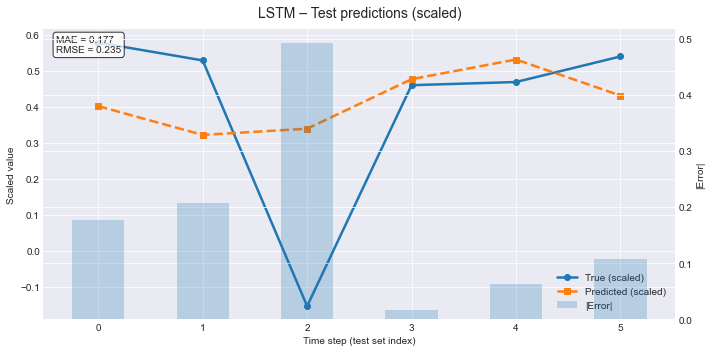

In [8]:
lstm_model = build_lstm_model()

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_lstm = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=8,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate
ytr_lstm, yv_lstm, yte_lstm = evaluate_and_print(
    lstm_model, 
    "LSTM", 
    X_train, y_train, 
    X_val, y_val, 
    X_test, y_test
)

# Plot some test predictions (scaled)
plot_predictions_scaled(y_test, yte_lstm, title="LSTM – Test predictions (scaled)", n_points=40)




Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - loss: 1.9921 - val_loss: 0.2713
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 1.6271 - val_loss: 0.2981
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 1.5398 - val_loss: 0.2830
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 1.5388 - val_loss: 0.2375
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 1.5530 - val_loss: 0.2076
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 1.5645 - val_loss: 0.2022
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 1.5572 - val_loss: 0.2052
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 1.5203 - val_loss: 0.2033
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 1.4621 - val_loss: 0.1995
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 1.3970 - val_loss: 0.1966
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 1.3377 - val_loss: 0.2025
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 1.2832 - val_lo

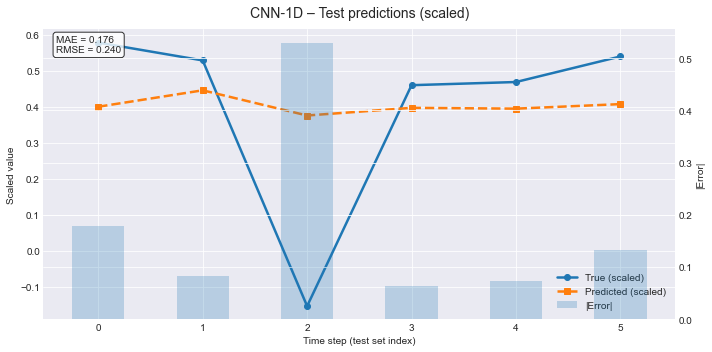

In [9]:
cnn_model = build_cnn1d_model()

history_cnn = cnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=8,
    callbacks=[early_stop],
    verbose=1
)

ytr_cnn, yv_cnn, yte_cnn = evaluate_and_print(
    cnn_model, 
    "CNN-1D", 
    X_train, y_train, 
    X_val, y_val, 
    X_test, y_test
)

plot_predictions_scaled(y_test, yte_cnn, title="CNN-1D – Test predictions (scaled)", n_points=40)


Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 127ms/step - loss: 1.9566 - val_loss: 0.2995
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 1.7252 - val_loss: 0.1552
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 1.6299 - val_loss: 0.1012
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 1.5793 - val_loss: 0.0892
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 1.5425 - val_loss: 0.0881
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 1.4974 - val_loss: 0.0854
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 1.4399 - val_loss: 0.0815
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 1.3774 - val_loss: 0.0802
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 1.3152 - val_loss: 0.0835
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 1.2568 - val_loss: 0.0895
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 1.2004 - val_loss: 0.0928
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 1.1487 - val_l

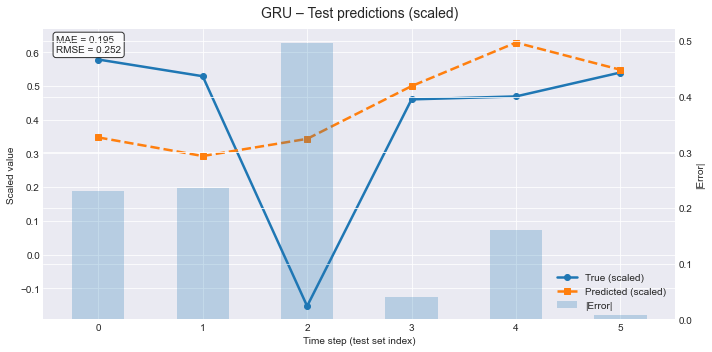

In [10]:
gru_model = build_gru_model()

history_gru = gru_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=8,
    callbacks=[early_stop],
    verbose=1
)

ytr_gru, yv_gru, yte_gru = evaluate_and_print(
    gru_model, 
    "GRU", 
    X_train, y_train, 
    X_val, y_val, 
    X_test, y_test
)

plot_predictions_scaled(y_test, yte_gru, title="GRU – Test predictions (scaled)", n_points=40)
